In [ ]:
import torch
import math
import mylib
from torch import nn

In [ ]:
def sequence_mask(X, valid_len, value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.shape[1]
    # PyTorch和Numpy中使用None来插入一个维度，从而自动广播
    mask = torch.arange((maxlen), dtype=torch.float32, 
                        device=X.device)[None, :] < valid_len[:, None]
    # 按位取反运算符~在 PyTorch 中对布尔张量被重载为逐元素逻辑非
    # Python中普通~是一个按位取反运算符（bitwise NOT）
    # 它对整数的二进制表示进行逐位取反操作 ~x == -x-1
    X[~mask] = value
    return X


def masked_softmax(X, valid_lens):
    """在最后一个轴上掩蔽元素再执行softmax操作"""
    # X: 3D张量，valid_lens: 1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            # 展平
            valid_lens = valid_lens.reshape(-1)
        # 将被遮蔽的元素用很大的负值替换，从而softmax输出为0
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)
    
        
class AdditiveAttention(nn.Module):
    """加性注意力"""
    # key_size为key的特征维度数, query_size为query的特征维度数
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.W_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hiddens)
        # key的形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.W_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size，“键－值”对的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)


class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries维数: (batch_size, queries个数, queries维数=d)
    # keys维数: (batch_size, key-value对个数, keys维数=d)
    # values维数: (batch_size, key-value对个数, 值的维度)
    # valid_lens维数: (batch_size, )或(batch_size, queries个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


torch.Size([2, 1, 10])


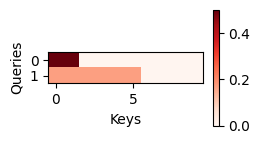

In [43]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                              dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)
print(attention.attention_weights.shape)
mylib.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                    xlabel='Keys', ylabel='Queries')


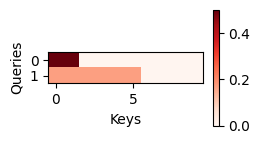

In [52]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens) 

mylib.show_heatmaps(attention.attention_weights.reshape(1, 1, 2, 10),
                    xlabel='Keys', ylabel="Queries")

Help on method_descriptor:

insert(self, index, object, /)
    Insert object before index.

